In [66]:
import numpy as np
import matplotlib.pyplot as plt
import json
from collections import defaultdict

sessions = []
with open("sessions.jsonl") as f:
    for line in f:
        line = line.strip()
        if line:
            sessions.append(json.loads(line))


unique_items = set()
for session in sessions:
    unique_items.update(session)
session_lengths = [len(s) for s in sessions]


freq = defaultdict(int)
for session in sessions:
    for item in session:
        freq[item] += 1

freq_without_dupl = defaultdict(int)
for session in sessions:
    unique_in_session = set(session)
    for item in unique_in_session:
        freq_without_dupl[item] += 1
freq_without_dupl_sorted = sorted(freq_without_dupl.items(), key=lambda x: x[1], reverse=True)
session_indices = range(len(sessions)) #Нужно будет для графика, где х - номер сессии
def train_test_split(
    sessions: list[list[int]],
) -> tuple[list[list[int]], list[int]]:
    train_sessions = [session[:-1] for session in sessions]
    test_targets = [session[-1] for session in sessions]
    return train_sessions, test_targets
#sessions — список списков целых чисел
print(f"Всего сессий: {len(sessions)}")
print(f"Первая сессия: {sessions[0]}")
print(f"Количество уникальных товаров: {len(unique_items)}")
print(f"Минимальная сессия: {np.min(session_lengths)}")
print(f"Максимальная сессия: {np.max(session_lengths)}")
print(f"Средняя длина сессии: {np.average(session_lengths):.2f}")
print(f"Медианная сессия: {np.median(session_lengths):.2f}")
print(f"Стандартное отклонение: {np.std(session_lengths):.2f}")
print("\nЧастота каждого товара с учетом повторов (ID: количество упоминаний):")
for item_id, count in sorted(freq.items(), key=lambda x: x[1], reverse=True)[:20]: #Отсортировал по самым частым упоминаниям (вкл повторы), топ 20
    print(f"  Товар {item_id}: {count}")

print(f"  Топ-20 встречающихся товаров (без учета повторов):")
for item_id, supp in freq_without_dupl_sorted[:20]:
    print(f"    Товар {item_id}: {supp} сессий")


Всего сессий: 2565
Первая сессия: [380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341, 293]
Количество уникальных товаров: 400
Минимальная сессия: 3
Максимальная сессия: 20
Средняя длина сессии: 10.47
Медианная сессия: 9.00
Стандартное отклонение: 5.90

Частота каждого товара с учетом повторов (ID: количество упоминаний):
  Товар 54: 2914
  Товар 335: 1691
  Товар 53: 1223
  Товар 114: 1067
  Товар 260: 833
  Товар 293: 736
  Товар 380: 571
  Товар 212: 510
  Товар 329: 492
  Товар 257: 450
  Товар 247: 394
  Товар 65: 383
  Товар 149: 366
  Товар 289: 320
  Товар 394: 299
  Товар 368: 268
  Товар 362: 240
  Товар 360: 225
  Товар 387: 224
  Товар 92: 223
  Топ-20 встречающихся товаров (без учета повторов):
    Товар 54: 1684 сессий
    Товар 335: 1111 сессий
    Товар 53: 940 сессий
    Товар 114: 781 сессий
    Товар 260: 622 сессий
    Товар 293: 595 сессий
    Товар 380: 486 сессий
    Товар 329: 429 сессий
    Товар 212: 414 сессий
    Товар 257: 396 се

### 2. Визуализация исходных данных

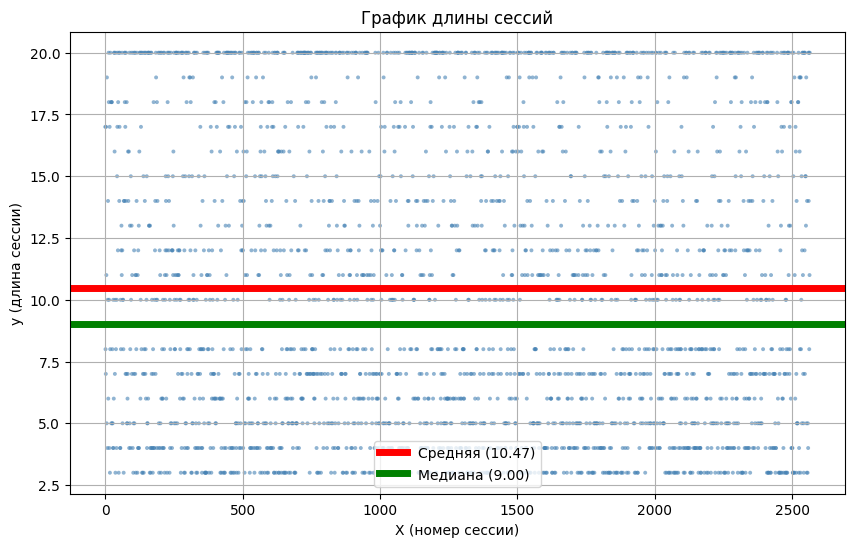

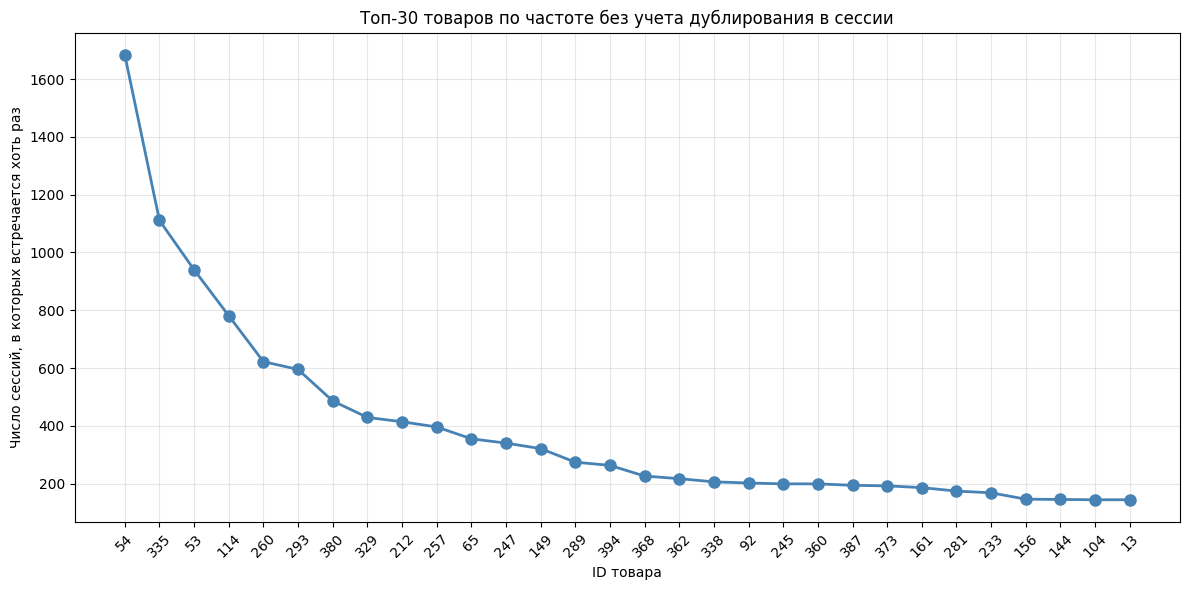

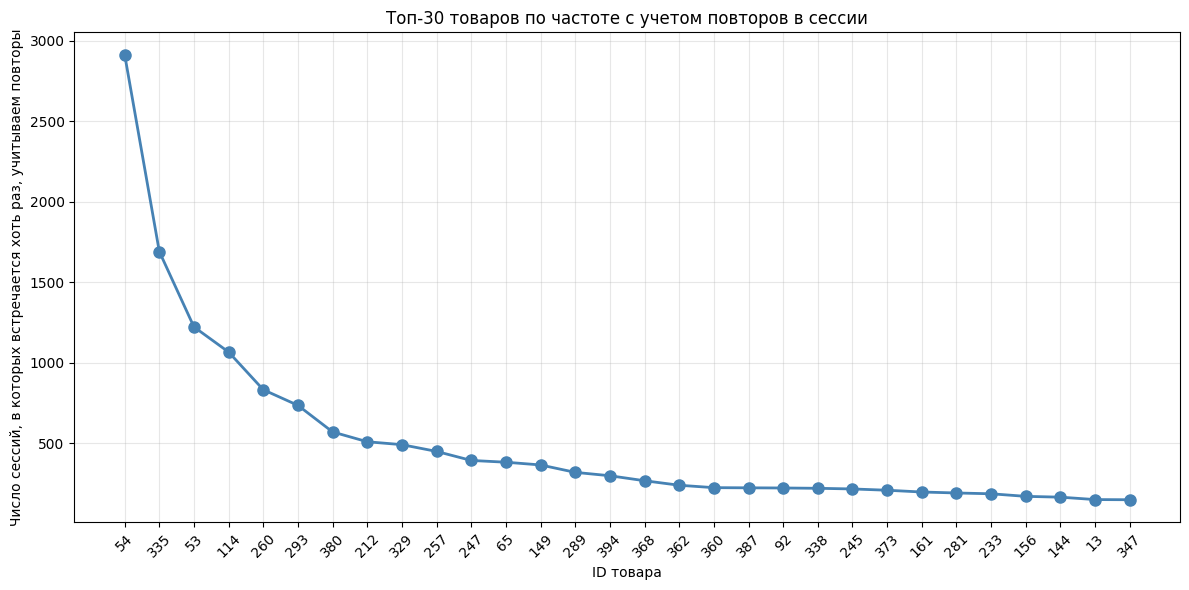

In [67]:
plt.figure(figsize=(10,6))
plt.scatter(session_indices,
            session_lengths,
            alpha=0.6,
            c='steelblue',
            edgecolors='none', s=8)
#Горизонтальная линия средней
plt.axhline(y=np.average(session_lengths),
            color='red',
            linewidth=5,
            label=f'Средняя ({np.average(session_lengths):.2f})')

#Горизонтальная линия медианы
plt.axhline(y=np.median(session_lengths),
            color='green',
            linewidth=5,
            label=f'Медиана ({np.median(session_lengths):.2f})')
plt.xlabel("X (номер сессии)")
plt.ylabel("y (длина сессии)")
plt.title("График длины сессий")
plt.grid(True)
plt.legend(loc='lower center')
plt.show()

top_items = freq_without_dupl_sorted[:30]
ids = [str(item) for item, _ in top_items]
support_values = [supp for _, supp in top_items]

plt.figure(figsize=(12, 6))
plt.plot(ids, support_values, marker='o', linestyle='-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('ID товара')
plt.ylabel('Число сессий, в которых встречается хоть раз')
plt.title('Топ-30 товаров по частоте без учета дублирования в сессии')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


top_items2 = sorted(freq.items(), key=lambda x: x[1], reverse=True)[:30]
ids2 = [str(item) for item, _ in top_items2]
support_values2 = [supp for _, supp in top_items2]

plt.figure(figsize=(12, 6))
plt.plot(ids2, support_values2, marker='o', linestyle='-', color='steelblue', linewidth=2, markersize=8)
plt.xlabel('ID товара')
plt.ylabel('Число сессий, в которых встречается хоть раз, учитываем повторы')
plt.title('Топ-30 товаров по частоте с учетом повторов в сессии')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### 3. Обучение модели линейной регрессии

In [68]:
train_sessions, test_targets = train_test_split(sessions)
print(f"Train sessions length: {len(train_sessions)}, Test targets length: {len(test_targets)}")
print(f"Train sessions {(train_sessions)}")
print(f"Test targets{(test_targets)}")
freq_without_dupl_train = defaultdict(int)
for session in train_sessions:
    unique_in_session = set(session)
    for item in unique_in_session:
        freq_without_dupl_train[item] += 1

freq_without_dupl_sorted_train = sorted(freq_without_dupl_train.items(), key=lambda x: x[1], reverse=True)

global_top1_item = freq_without_dupl_sorted_train[0][0]
global_top2_item = freq_without_dupl_sorted_train[1][0] if len(freq_without_dupl_sorted_train) > 1 else None
global_popular_items_train = [item for item, _ in freq_without_dupl_sorted_train]
def build_transition_graph(train_sessions):

    transitions = defaultdict(lambda: defaultdict(int))

    for session in train_sessions:
        for idx in range(len(session) - 1):
            item_from = session[idx]
            item_to = session[idx + 1]
            transitions[item_from][item_to] += 1

    #Подсчитываем суммарное число переходов из каждого товара (потом для вероятности нужно будет)
    total_out = {item: sum(targets.values()) for item, targets in transitions.items()}
    return transitions, total_out
transitions, total_out = build_transition_graph(train_sessions)

top_next = {}
for i, targets in transitions.items():
    #targets — словарь {j: количество переходов}
    #выбираем j с максимальным количеством переходов
    best_j = max(targets, key=lambda j: targets[j])
    top_next[i] = best_j
def simple_p_j_given_i(i, j, transitions, total_out):

    total = total_out.get(i, 0)
    if total == 0:
        return 0.0
    count = transitions.get(i, {}).get(j, 0)
    return count / total
def recommend_one(item):
    """
    Возвращает один ID товара, который рекомендуется сразу после item. Если для item есть переходы - самый частый последователь, если переходов нет - глобально самый популярный товар (топ-1).
    Но если item сам является топ-1, то даём топ-2 (чтобы не рекомендовать его самого).
    """
    if item in top_next:
        return top_next[item]
    if item == global_top1_item and global_top2_item is not None:
        return global_top2_item
    else:
        return global_top1_item
def recommend_top10(last_item, top_n=10):


    known_transitions = transitions.get(last_item, {})


    sorted_direct = [j for j, _ in sorted(known_transitions.items(), key=lambda x: x[1], reverse=True)]


    if not sorted_direct:
        #Берём товары из freq_without_dupl_sorted, исключая сам last_item
        fallback = [item for item, _ in freq_without_dupl_sorted_train if item != last_item]
        return fallback[:top_n]

    #Если прямых кандидатов меньше top_n, добираем из популярных
    if len(sorted_direct) < top_n:
        needed = top_n - len(sorted_direct)

        extra = [item for item, _ in freq_without_dupl_sorted_train if item != last_item and item not in sorted_direct]
        sorted_direct.extend(extra[:needed])

    return sorted_direct[:top_n]

print("Рекомендации после 42:", recommend_top10(42))

print("Рекомендации после нового товара 9999:", recommend_top10(9999))
def hit_at_k(
    recommendations: list[list[int]],
    true_items: list[int],
    k: int = 10,
) -> float:
    """
    Вычисление Hit@K для списка предсказаний.

    Parameters
    ----------
    recommendations : list of lists of ints
        recommendations[i] — ранжированный список
        рекомендаций для i-го примера.
    true_items : list of ints
        true_items[i] — истинный следующий товар
        для i-го примера.
    k : int
        Отсечка top-K (по умолчанию 10).

    Returns
    -------
    float
        Hit@K, значение от 0 до 1.
    """
    assert len(recommendations) == len(true_items), \
        "recommendations и true_items должны совпадать по длине"

    hits = 0
    for recs, true_item in zip(recommendations, true_items):
        if true_item in recs[:k]:
            hits += 1

    return hits / len(true_items)

#Глобальный список популярных товаров (для бейзлайна)
global_popular_items = global_popular_items_train

def baseline_recommend_top10(last_item: int) -> list[int]:

    recs = [item for item in global_popular_items if item != last_item]
    return recs[:10]

#Формируем рекомендации для всех тестовых примеров
model_recommendations = []
baseline_recommendations = []

for i in range(len(test_targets)):
    #Последний известный товар в обучающей части сессии
    last_known = train_sessions[i][-1]

    #Рекомендации модели
    recs_model = recommend_top10(last_known)
    model_recommendations.append(recs_model)

    # Рекомендации бейзлайна
    recs_baseline = baseline_recommend_top10(last_known)
    baseline_recommendations.append(recs_baseline)


hit_model = hit_at_k(model_recommendations, test_targets, k=10)
hit_baseline = hit_at_k(baseline_recommendations, test_targets, k=10)

print(f"Hit@10 модели (граф переходов): {hit_model:.4f} ({hit_model*100:.2f}%)")
print(f"Hit@10 бейзлайна (топ-10 популярных): {hit_baseline:.4f} ({hit_baseline*100:.2f}%)")




Train sessions length: 2565, Test targets length: 2565
Train sessions [[380, 293, 262, 114, 123, 345, 335, 245, 272, 293, 233, 302, 247, 290, 260, 341], [53, 54, 53, 65, 53, 335, 286], [54, 397, 398, 294, 223, 293], [335, 54, 335, 221, 41, 247, 380, 114, 43, 111, 257, 335, 54, 62, 387, 362], [252, 301, 387, 212, 246, 61, 175, 392, 370, 233], [53, 398, 104, 148], [260, 149, 260, 92, 13, 385, 156, 65, 104, 54, 329, 54, 394, 76, 189, 287, 5, 11], [257, 62, 362, 212, 15, 349, 247, 397], [335, 396, 156], [53, 114, 380, 46, 360, 85, 42, 54, 53], [368, 114, 293, 114, 335, 289, 368, 286, 335, 233, 293, 260, 54], [190, 31, 281, 387, 212], [335, 216, 335, 38, 312, 260, 241, 161, 104, 302, 380, 114, 37, 380, 293, 191, 380, 293, 149], [207, 28, 301, 362, 387, 212, 336, 335, 238, 149, 161, 293, 164, 293, 380, 293, 260], [326, 156, 144, 335, 59, 367, 92, 335, 373], [161, 334, 78], [308, 243, 385, 64, 257, 54, 77, 329, 144, 219, 242, 368, 209, 199, 97, 151], [92, 260], [293, 114, 55, 28, 54, 338, 379